<a href="https://colab.research.google.com/github/JMR825/Machine_learning-Notebook/blob/main/EDA_practice1_California_housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“Given the location and demographic features of a district, predict its median house value.”

In [130]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
camnugent_california_housing_prices_path = kagglehub.dataset_download('camnugent/california-housing-prices')

print('Data source import complete.')


Using Colab cache for faster access to the 'california-housing-prices' dataset.
Data source import complete.


In [131]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/california-housing-prices/housing.csv


In [132]:
data=pd.read_csv('/content/sample_data/california_housing_train.csv')

In [133]:
#check missing
data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


I'm engineering features here

In [134]:
data['rooms_per_household']=data['total_rooms']/data['households']
data['bedrooms_per_room']=data['total_bedrooms']/data['total_rooms']
data['population_per_household']=data['population']/data['households']

In [135]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353,5.439044,0.212760,2.976337
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387,2.539196,0.057823,4.037838
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000,4.445275,0.175058,2.432609
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000,5.236106,0.202943,2.816872
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000,6.058097,0.239867,3.279435
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,502.461538


In [136]:
x=data.drop('median_house_value',axis=1)
y=data['median_house_value']


In [137]:
#train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#shapes
x_train.shape,x_test.shape,y_train.shape,y_test.shape
#applying scaler
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
#

In [138]:
#linear model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)
y_pred=lin_reg.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

In [139]:
print(mae)
print(rmse)
print(r2)

49205.626750787604
67471.94259732598
0.6696049644359154


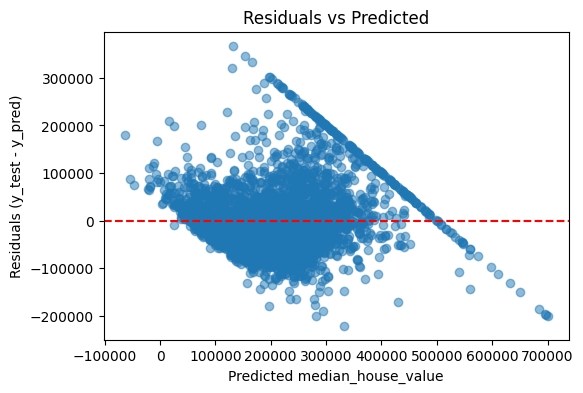

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# residuals
residuals = y_test - y_pred

# scatter: predicted vs residuals
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')  # zero line
plt.xlabel('Predicted median_house_value')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residuals vs Predicted')
plt.show()

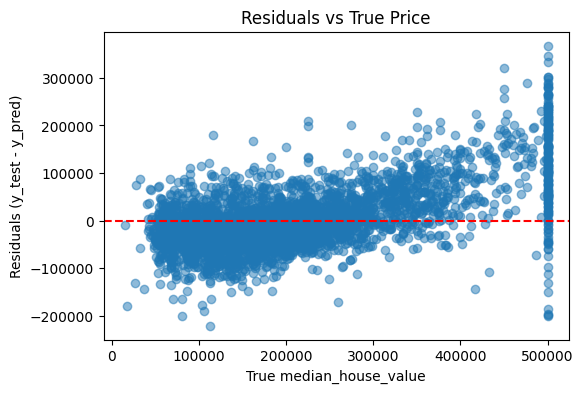

In [141]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True median_house_value')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residuals vs True Price')
plt.show()

In [142]:
import joblib

# save scaler
joblib.dump(scaler, 'scaler.joblib')

# save model
joblib.dump(lin_reg, 'rf_model.joblib')

['rf_model.joblib']

In [143]:
#random forest Tree
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor()
rf_reg.fit(x_train,y_train)
y_pred=rf_reg.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

In [144]:
print(mae)
print(rmse)
print(r2)

33107.45175882353
50570.15946148231
0.8144009577110108


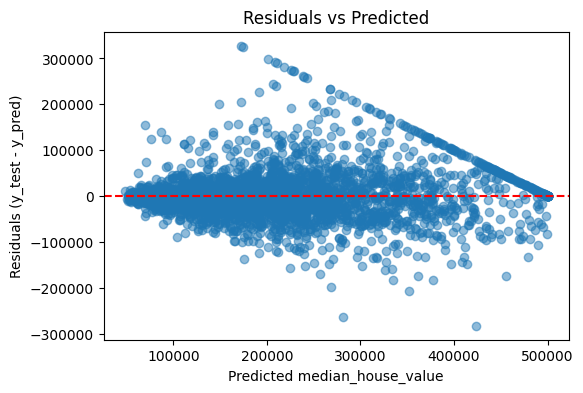

In [145]:
import numpy as np
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')  # zero line
plt.xlabel('Predicted median_house_value')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residuals vs Predicted')
plt.show()

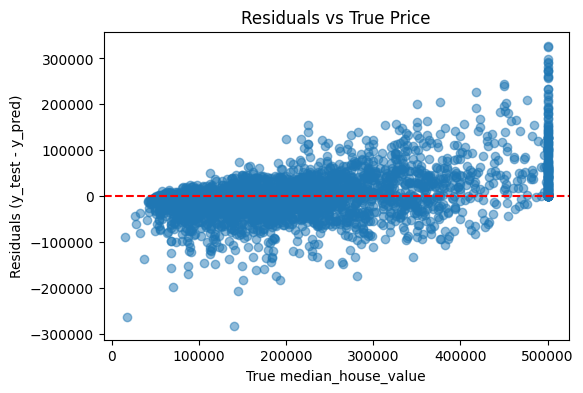

In [146]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True median_house_value')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residuals vs True Price')
plt.show()

In [147]:
import joblib

# save scaler
joblib.dump(scaler, 'scaler.joblib')

# save model
joblib.dump(rf_reg, 'rf_model.joblib')

['rf_model.joblib']